In [1]:
import tensorflow as tf 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

I0000 00:00:1787739608.047598   30300 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787739608.080811   30300 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787739609.091772   30300 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
data = pd.read_csv("AAPL.csv")
prices = data['Close'].values
# print(prices)

# Normalize the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

prices_scaled = scaler.fit_transform(prices.reshape(-1,1))


In [15]:
def create_sequences(data,seq_length):
    X = []
    y = []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X),np.array(y)

seq_length = 60 # Use the past 60 days to predict the next day 

X,y = create_sequences(prices_scaled,seq_length)

split = int(0.8*len(X))
X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10776, 60, 1)
y shape: (10776, 1)


In [16]:
# Reshape the input data
X_train = X_train.reshape((X_train.shape[0],seq_length,1))
X_test = X_test.reshape((X_test.shape[0],seq_length,1))

# Define the model

model = tf.keras.Sequential([tf.keras.layers.LSTM(50,return_sequences=True,input_shape = (seq_length,1)),
                             tf.keras.layers.LSTM(50),tf.keras.layers.Dense(1)])

model.compile(optimizer = 'adam',loss = 'mean_squared_error')

/home/bhoopender/tensorflow/tensorflow/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
history = model.fit(X_train,y_train,epochs=25,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/25


270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.1419e-05 - val_loss: 0.0028
Epoch 2/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.9969e-06 - val_loss: 8.3613e-04
Epoch 3/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.9491e-06 - val_loss: 8.7694e-04
Epoch 4/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.9942e-06 - val_loss: 7.3662e-04
Epoch 5/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.7296e-06 - val_loss: 0.0012
Epoch 6/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.3634e-06 - val_loss: 3.4545e-04
Epoch 7/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.6506e-06 - val_loss: 5.8482e-04
Epoch 8/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.3610e-06 - val_loss: 3.5262e-04
Epoch 9/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.1014e-06 - val_loss: 0.0018
Epoch 10/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2.2502e-06 - val_loss: 4.8589e-04
Epoch 11/25
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.9071e-06 - val_loss

In [19]:
# Predict on test Data 
predictions = model.predict(X_test)

#Inverse transform to get actual prices 

predictions_inverse = scaler.inverse_transform(predictions)

y_test_inverse = scaler.inverse_transform(y_test.reshape(-1,1))

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


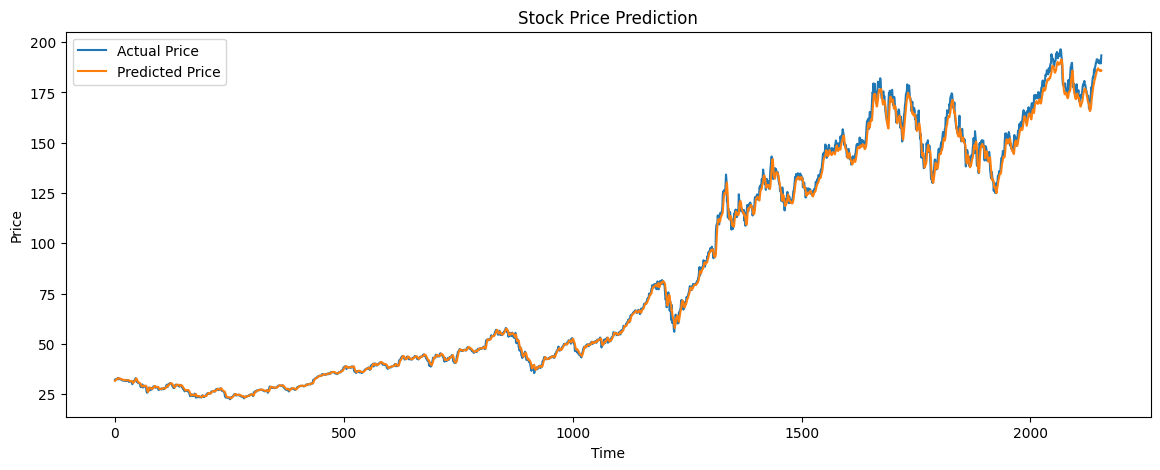

In [20]:
plt.figure(figsize=(14,5))
plt.plot(y_test_inverse,label ='Actual Price')
plt.plot(predictions_inverse,label='Predicted Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

mse = mean_squared_error(y_test_inverse,predictions_inverse)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inverse,predictions_inverse)

print(f"MSE:{mse:.4f}")
print(f"RMSE:{rmse:.4f}")
print(f"MAE:{mae:.4f}")


MSE:6.6702
RMSE:2.5827
MAE:1.6329
